In [1]:
!pip install transformers torch langgraph -q

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from transformers import pipeline

C:\Users\nagar\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
generator = pipeline(
    "text-generation",
    model="distilgpt2"   # lightweight model (fast)
)

c:\Users\nagar\anaconda3\envs\ns_agentic_ai\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nagar\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 2071.91it/s]


In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    
    prompt = f"Generate a blog outline on: {title}\n"
    
    result = generator(prompt, max_length=150, num_return_sequences=1)
    outline = result[0]['generated_text']
    
    state['outline'] = outline
    return state


def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    prompt = f"Write a blog on: {title}\nOutline:\n{outline}\n"
    
    result = generator(prompt, max_length=400, num_return_sequences=1)
    content = result[0]['generated_text']
    
    state['content'] = content
    return state

In [6]:
graph = StateGraph(BlogState)

# Nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# Edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

# Compile
workflow = graph.compile()

# Input
initial_state = {
    "title": "Rise of AI in India",
    "outline": "",
    "content": ""
}

# Run
final_state = workflow.invoke(initial_state)

# Output
print("=== OUTLINE ===")
print(final_state['outline'])

print("\n=== BLOG ===")
print(final_state['content'])

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=400) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== OUTLINE ===
Generate a blog outline on: Rise of AI in India


































































































































































































































































=== BLOG ===
Write a blog on: Rise of AI in India
Outline:
Generate a blog outline on: Rise of AI in India





































































































































































































































































































































































































































































































































### 2nd Type

In [7]:
!pip install transformers torch langgraph matplotlib -q

In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from transformers import pipeline
import matplotlib.pyplot as plt
import networkx as nx

In [9]:
generator = pipeline(
    "text-generation",
    model="gpt2"   # better than distilgpt2
)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1263.28it/s]


In [10]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [11]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    
    prompt = f"Generate a structured blog outline on: {title}\n"
    
    result = generator(prompt, max_length=150, num_return_sequences=1)
    outline = result[0]['generated_text']
    
    state['outline'] = outline
    return state


def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    prompt = f"Write a well-formatted blog on: {title}\nOutline:\n{outline}\n"
    
    result = generator(prompt, max_length=400, num_return_sequences=1)
    content = result[0]['generated_text']
    
    state['content'] = content
    return state

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=400) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🧠 BLOG TITLE
Rise of AI in India

📌 BLOG OUTLINE
Generate a structured blog outline on: Rise of AI in India

Create a blog outline on: Why AI is driving the rise of AI in India

Reach out to experts on: How AI is driving the rise of AI in India

Reach out to experts on: How AI is driving the rise of AI in India Start a new Business with a new Blog with a new Business Start a new Business with a new Blog with a new Blog with a new Blog with a new Business Start a new Business with a new Blog with a new Blog with a new Business Start a new Business with a new Blog with a new Blog with a new Business Start a new Business with a new Blog with a new Business Start a new Business with a new Blog Start a new Business with a new Blog Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new Business Start a new

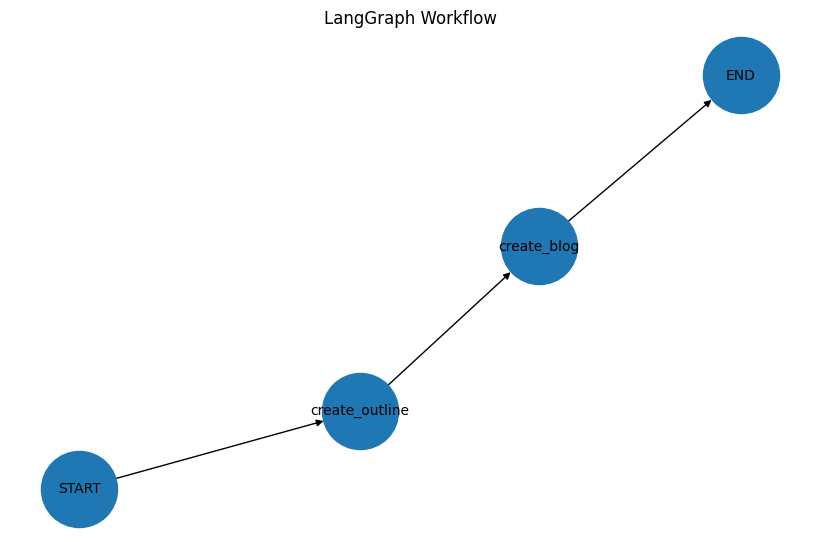

In [12]:
# Build LangGraph
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

workflow = graph.compile()

# Input
initial_state = {
    "title": "Rise of AI in India",
    "outline": "",
    "content": ""
}

# Run
final_state = workflow.invoke(initial_state)

# =========================
# ✅ CLEAN FORMATTED OUTPUT
# =========================

print("\n" + "="*50)
print("🧠 BLOG TITLE")
print("="*50)
print(final_state['title'])

print("\n" + "="*50)
print("📌 BLOG OUTLINE")
print("="*50)
print(final_state['outline'])

print("\n" + "="*50)
print("📝 BLOG CONTENT")
print("="*50)
print(final_state['content'])


# =========================
# ✅ GRAPH VISUALIZATION
# =========================

G = nx.DiGraph()

# Nodes
G.add_node("START")
G.add_node("create_outline")
G.add_node("create_blog")
G.add_node("END")

# Edges
G.add_edge("START", "create_outline")
G.add_edge("create_outline", "create_blog")
G.add_edge("create_blog", "END")

plt.figure(figsize=(8,5))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10)
plt.title("LangGraph Workflow")
plt.show()